# Los Angeles County Housing Market Analysis (2022–2025)

This project studies home-price growth and housing supply–demand conditions in Los Angeles County using monthly Redfin county-level data.

**Main questions**
1. How did Los Angeles County home prices change from 2022 to 2025?
2. How did active listings and new listings change?
3. How did sales, pending sales, and days on market change?
4. What relationship appears between housing supply and prices?

## 1. Import libraries and load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

file_path = "redfin_county_housing_2022_2025.csv"
df = pd.read_csv(file_path)
df.head()

,LAST UPDATED,FREQUENCY,PERIOD BEGIN,PERIOD END,REGION ID,REGION TYPE,REGION NAME,METRO,HOMES SOLD,HOMES SOLD YOY (%),MEDIAN SALE PRICE NSA ($),MEDIAN SALE PRICE NSA YOY (%),MEDIAN DAYS ON MARKET (DAYS),MEDIAN DAYS ON MARKET YOY (%),NEW LISTINGS,NEW LISTINGS YOY (%),ACTIVE LISTINGS,ACTIVE LISTINGS YOY (%),PENDING SALES,PENDING SALES YOY (%),MEDIAN NEW LISTING PRICE PER SQ.FT. ($),MEDIAN NEW LISTING PRICE PER SQ.FT. YOY (%)
0,2026-08-03,Monthly,2025-12-01,2025-12-31,1892,County,"Bergen County, NJ","New York, NY metro area",690.0,-3.77,755000.0,6.34,79.0,900.0,366.0,14.02,2619,7.51,506.0,42.54,434.34,4.05
1,2026-08-03,Monthly,2025-12-01,2025-12-31,1947,County,"Bronx County, NY","New York, NY metro area",183.0,7.65,636000.0,-4.65,53.0,-1100.0,208.0,24.55,1339,9.57,194.0,16.87,404.46,9.36
2,2026-08-03,Monthly,2025-12-01,2025-12-31,1899,County,"Hudson County, NJ","New York, NY metro area",380.0,-3.55,720000.0,3.97,57.0,1300.0,294.0,2.80,1800,10.77,338.0,6.29,491.05,3.72
3,2026-08-03,Monthly,2025-12-01,2025-12-31,1968,County,"Kings County, NY","New York, NY metro area",593.0,-5.27,999990.0,0.10,65.0,1700.0,472.0,-14.80,3938,6.17,560.0,-8.20,672.04,-7.12
4,2026-08-03,Monthly,2025-12-01,2025-12-31,1975,County,"New York County, NY","New York, NY metro area",771.0,-2.53,1255000.0,4.58,94.0,2400.0,472.0,-30.38,5922,7.67,783.0,3.16,1402.46,-10.64


## 2. Inspect data quality

In [3]:
print("Dataset shape:", df.shape)
print("\nDate range:", df["PERIOD BEGIN"].min(), "to", df["PERIOD BEGIN"].max())
print("\nRegion types:")
print(df["REGION TYPE"].value_counts())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nMissing values by column:")
print(df.isna().sum())

Dataset shape: (16080, 22)

Date range: 2022-01-01 to 2025-12-01

Region types:
REGION TYPE
County    16080
Name: count, dtype: int64

Duplicate rows: 0

Missing values by column:
LAST UPDATED                                    0
FREQUENCY                                       0
PERIOD BEGIN                                    0
PERIOD END                                      0
REGION ID                                       0
REGION TYPE                                     0
REGION NAME                                     0
METRO                                           0
HOMES SOLD                                      7
HOMES SOLD YOY (%)                             13
MEDIAN SALE PRICE NSA ($)                       7
MEDIAN SALE PRICE NSA YOY (%)                  13
MEDIAN DAYS ON MARKET (DAYS)                    8
MEDIAN DAYS ON MARKET YOY (%)                  15
NEW LISTINGS                                    7
NEW LISTINGS YOY (%)                           14
ACTIVE LISTINGS     

In [4]:
# Confirm the exact region name before filtering.
df.loc[
    df["REGION NAME"].str.contains("Los Angeles", case=False, na=False),
    ["REGION NAME", "METRO"]
].drop_duplicates()

,REGION NAME,METRO
11,"Los Angeles County, CA","Los Angeles, CA metro area"


## 3. Filter Los Angeles County and prepare variables

In [5]:
la = df.loc[
    (df["REGION TYPE"] == "County") &
    (df["REGION NAME"] == "Los Angeles County, CA")
].copy()

la["PERIOD BEGIN"] = pd.to_datetime(la["PERIOD BEGIN"])
la["PERIOD END"] = pd.to_datetime(la["PERIOD END"])
la = la.sort_values("PERIOD BEGIN").reset_index(drop=True)

la["YEAR"] = la["PERIOD BEGIN"].dt.year
la["MONTH"] = la["PERIOD BEGIN"].dt.month
la["YEAR_MONTH"] = la["PERIOD BEGIN"].dt.to_period("M").astype(str)

print("LA County rows:", len(la))
print("Date range:", la["PERIOD BEGIN"].min(), "to", la["PERIOD BEGIN"].max())
print("\nRows per year:")
print(la.groupby("YEAR").size())

LA County rows: 48
Date range: 2022-01-01 00:00:00 to 2025-12-01 00:00:00

Rows per year:
YEAR
2022    12
2023    12
2024    12
2025    12
dtype: int64


In [6]:
key_columns = [
    "PERIOD BEGIN",
    "MEDIAN SALE PRICE NSA ($)",
    "HOMES SOLD",
    "ACTIVE LISTINGS",
    "NEW LISTINGS",
    "PENDING SALES",
    "MEDIAN DAYS ON MARKET (DAYS)"
]

print(la[key_columns].isna().sum())
la[key_columns].head()

PERIOD BEGIN                    0
MEDIAN SALE PRICE NSA ($)       0
HOMES SOLD                      0
ACTIVE LISTINGS                 0
NEW LISTINGS                    0
PENDING SALES                   0
MEDIAN DAYS ON MARKET (DAYS)    0
dtype: int64


,PERIOD BEGIN,MEDIAN SALE PRICE NSA ($),HOMES SOLD,ACTIVE LISTINGS,NEW LISTINGS,PENDING SALES,MEDIAN DAYS ON MARKET (DAYS)
0,2022-01-01,825000.0,4816.0,14514,5901.0,5440.0,39.0
1,2022-02-01,840000.0,4688.0,15682,6640.0,6135.0,32.0
2,2022-03-01,875000.0,6596.0,17651,7867.0,7136.0,28.0
3,2022-04-01,900000.0,6390.0,18168,7843.0,6863.0,27.0
4,2022-05-01,900000.0,6035.0,19269,8000.0,6829.0,27.0


## 4. Create an annual summary

Price, inventory, listings, pending sales, and days on market are summarized as averages of the 12 monthly observations. Homes sold is summed because it is a monthly flow measure.

In [7]:
annual = la.groupby("YEAR").agg(
    avg_monthly_median_price=("MEDIAN SALE PRICE NSA ($)", "mean"),
    total_homes_sold=("HOMES SOLD", "sum"),
    avg_active_listings=("ACTIVE LISTINGS", "mean"),
    avg_new_listings=("NEW LISTINGS", "mean"),
    avg_pending_sales=("PENDING SALES", "mean"),
    avg_days_on_market=("MEDIAN DAYS ON MARKET (DAYS)", "mean")
).reset_index()

annual["price_growth_pct"] = annual["avg_monthly_median_price"].pct_change() * 100
annual["inventory_change_pct"] = annual["avg_active_listings"].pct_change() * 100
annual["sales_change_pct"] = annual["total_homes_sold"].pct_change() * 100

annual.round(2)

,YEAR,avg_monthly_median_price,total_homes_sold,avg_active_listings,avg_new_listings,avg_pending_sales,avg_days_on_market,price_growth_pct,inventory_change_pct,sales_change_pct
0,2022,851500.00,61106.0,18822.75,6324.25,5612.92,36.58,NaN,NaN,NaN
1,2023,845770.83,47572.0,16032.17,4879.25,4584.08,40.00,-0.67,-14.83,-22.15
2,2024,894145.83,49706.0,19033.67,5570.92,4801.75,40.92,5.72,18.72,4.49
3,2025,913583.33,49981.0,23101.42,5861.08,4808.83,49.92,2.17,21.37,0.55


## 5. Problem Statement

This project examines how home prices changed in Los Angeles County from 2022 to 2025 and explores how housing supply and demand indicators were related to these price changes.

The analysis focuses on four questions:

1. How much did home prices change from 2022 to 2025?
2. How did housing supply change during this period?
3. How did sales activity and market demand change?
4. What relationship can be observed between housing supply, demand, and home prices?

## 6. Problem 1: How Did Home Prices Change?

This section examines how home prices changed in Los Angeles County from 2022 to 2025. It compares monthly price trends, annual average prices, year-over-year growth, and the cumulative price change between the beginning and end of the study period.

In [16]:
price_summary = annual[
    [
        "YEAR",
        "avg_monthly_median_price",
        "price_growth_pct"
    ]
].copy()

price_summary.columns = [
    "Year",
    "Average Monthly Median Price",
    "Annual Price Growth (%)"
]

price_summary.round(2)

,Year,Average Monthly Median Price,Annual Price Growth (%)
0,2022,851500.00,NaN
1,2023,845770.83,-0.67
2,2024,894145.83,5.72
3,2025,913583.33,2.17


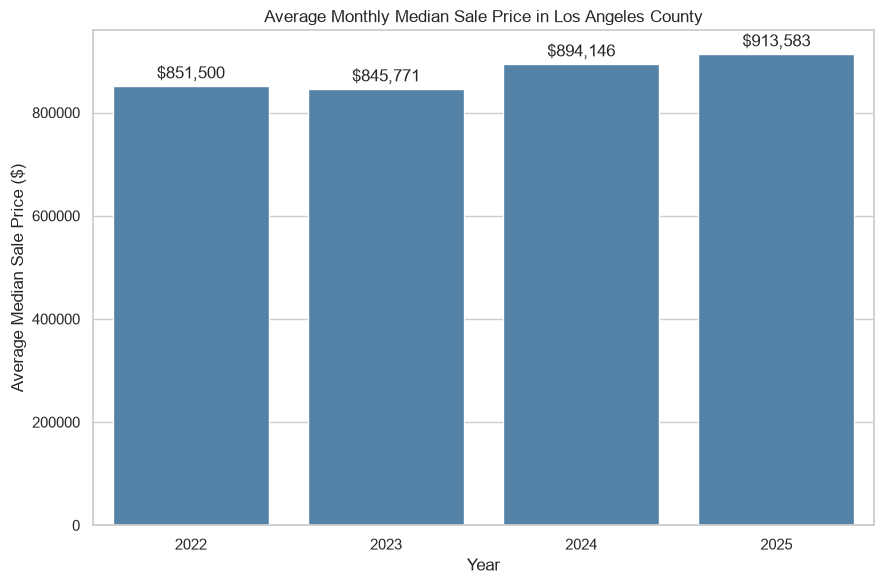

In [17]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=price_summary,
    x="Year",
    y="Average Monthly Median Price",
    color="steelblue"
)

plt.title(
    "Average Monthly Median Sale Price in Los Angeles County"
)
plt.xlabel("Year")
plt.ylabel("Average Median Sale Price ($)")
plt.ticklabel_format(style="plain", axis="y")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"${value:,.0f}"
            for value in price_summary[
                "Average Monthly Median Price"
            ]
        ],
        padding=3
    )

plt.tight_layout()
plt.show()

In [18]:
start_row = la.iloc[0]
end_row = la.iloc[-1]

start_price = start_row["MEDIAN SALE PRICE NSA ($)"]
end_price = end_row["MEDIAN SALE PRICE NSA ($)"]

cumulative_price_growth = (
    (end_price / start_price) - 1
) * 100

print(
    f"Starting price ({start_row['PERIOD BEGIN']:%B %Y}): "
    f"${start_price:,.0f}"
)

print(
    f"Ending price ({end_row['PERIOD BEGIN']:%B %Y}): "
    f"${end_price:,.0f}"
)

print(
    f"Cumulative price growth: "
    f"{cumulative_price_growth:.2f}%"
)

Starting price (January 2022): $825,000
Ending price (December 2025): $890,000
Cumulative price growth: 7.88%


### Analysis

Los Angeles County home prices increased overall between 2022 and 2025, although the growth was not continuous.

The average monthly median sale price decreased slightly from approximately $851,500 in 2022 to $845,771 in 2023, representing a decline of 0.67%. The market then experienced stronger price growth in 2024, when the annual average increased by 5.72% to approximately $894,146. In 2025, the average price increased by another 2.17% to approximately $913,583.

Comparing the first and last months of the study period, the median sale price increased from $825,000 in January 2022 to $890,000 in December 2025. This represents a cumulative increase of approximately 7.88%.

Therefore, the data show that Los Angeles County home prices remained relatively resilient. Prices weakened slightly in 2023 but recovered and reached a higher annual average in 2025.

## 7. Problem 2: How Did Housing Supply Change?

This section examines changes in housing supply in Los Angeles County from 2022 to 2025.

Active listings represent the number of homes available for sale, while new listings represent homes newly added to the market during each month. These two indicators help measure the availability of housing options for buyers.

In [19]:
supply_summary = annual[
    [
        "YEAR",
        "avg_active_listings",
        "avg_new_listings",
        "inventory_change_pct"
    ]
].copy()

supply_summary.columns = [
    "Year",
    "Average Active Listings",
    "Average New Listings",
    "Inventory Change (%)"
]

supply_summary.round(2)

,Year,Average Active Listings,Average New Listings,Inventory Change (%)
0,2022,18822.75,6324.25,NaN
1,2023,16032.17,4879.25,-14.83
2,2024,19033.67,5570.92,18.72
3,2025,23101.42,5861.08,21.37


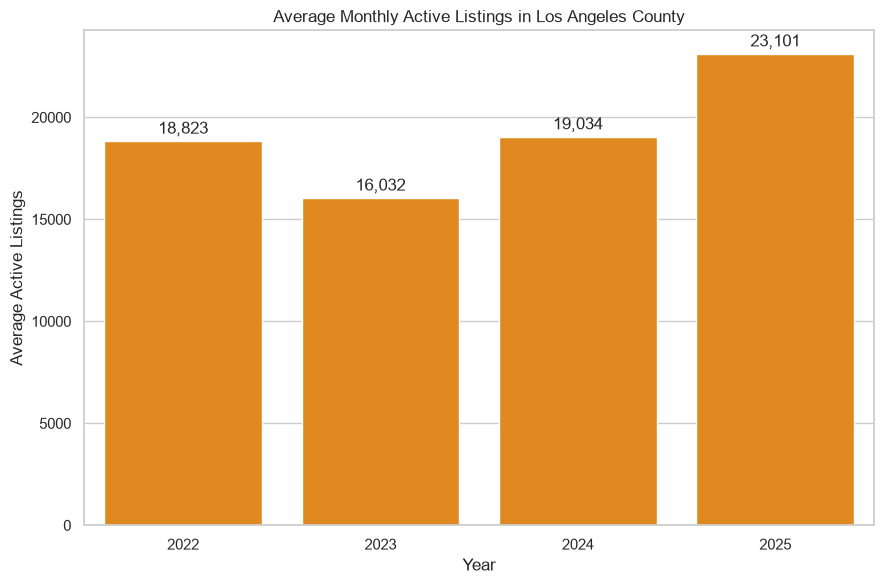

In [20]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=supply_summary,
    x="Year",
    y="Average Active Listings",
    color="darkorange"
)

plt.title(
    "Average Monthly Active Listings in Los Angeles County"
)
plt.xlabel("Year")
plt.ylabel("Average Active Listings")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value:,.0f}"
            for value in supply_summary[
                "Average Active Listings"
            ]
        ],
        padding=3
    )

plt.tight_layout()
plt.show()

In [21]:
inventory_2022 = supply_summary.loc[
    supply_summary["Year"] == 2022,
    "Average Active Listings"
].iloc[0]

inventory_2025 = supply_summary.loc[
    supply_summary["Year"] == 2025,
    "Average Active Listings"
].iloc[0]

inventory_total_change = (
    inventory_2025 / inventory_2022 - 1
) * 100

print(
    f"Average active listings in 2022: "
    f"{inventory_2022:,.0f}"
)

print(
    f"Average active listings in 2025: "
    f"{inventory_2025:,.0f}"
)

print(
    f"Change from 2022 to 2025: "
    f"{inventory_total_change:.2f}%"
)

Average active listings in 2022: 18,823
Average active listings in 2025: 23,101
Change from 2022 to 2025: 22.73%


### Analysis

Housing supply in Los Angeles County declined in 2023 before recovering strongly in 2024 and 2025.

Average active listings decreased from approximately 18,823 in 2022 to 16,032 in 2023, representing a decline of 14.83%. Average new listings also decreased from approximately 6,324 per month to 4,879 during the same period. These results indicate that fewer homes were available and fewer properties entered the market in 2023.

Housing supply began to recover in 2024. Average active listings increased by 18.72% to approximately 19,034 and then increased by another 21.37% to approximately 23,101 in 2025.

Compared with 2022, average active inventory was approximately 22.73% higher in 2025. However, average new listings in 2025 remained below their 2022 level. This suggests that the increase in active inventory may have been influenced not only by new supply, but also by homes taking longer to sell.

Overall, buyers had more available housing options in 2025 than in 2023, but the increase in active listings does not necessarily mean that the long-term housing shortage in Los Angeles County was resolved.

## 8. Problem 3: How Did Housing Demand and Market Activity Change?

This section examines changes in housing demand and market activity in Los Angeles County from 2022 to 2025.

Homes sold and pending sales are used as indicators of completed and near-term market activity. Median days on market is used to measure how quickly homes sold. Together, these indicators provide an indirect measure of buyer activity and market competition.

In [22]:
demand_summary = annual[
    [
        "YEAR",
        "total_homes_sold",
        "avg_pending_sales",
        "avg_days_on_market",
        "sales_change_pct"
    ]
].copy()

demand_summary.columns = [
    "Year",
    "Total Homes Sold",
    "Average Pending Sales",
    "Average Days on Market",
    "Sales Change (%)"
]

demand_summary.round(2)

,Year,Total Homes Sold,Average Pending Sales,Average Days on Market,Sales Change (%)
0,2022,61106.0,5612.92,36.58,NaN
1,2023,47572.0,4584.08,40.00,-22.15
2,2024,49706.0,4801.75,40.92,4.49
3,2025,49981.0,4808.83,49.92,0.55


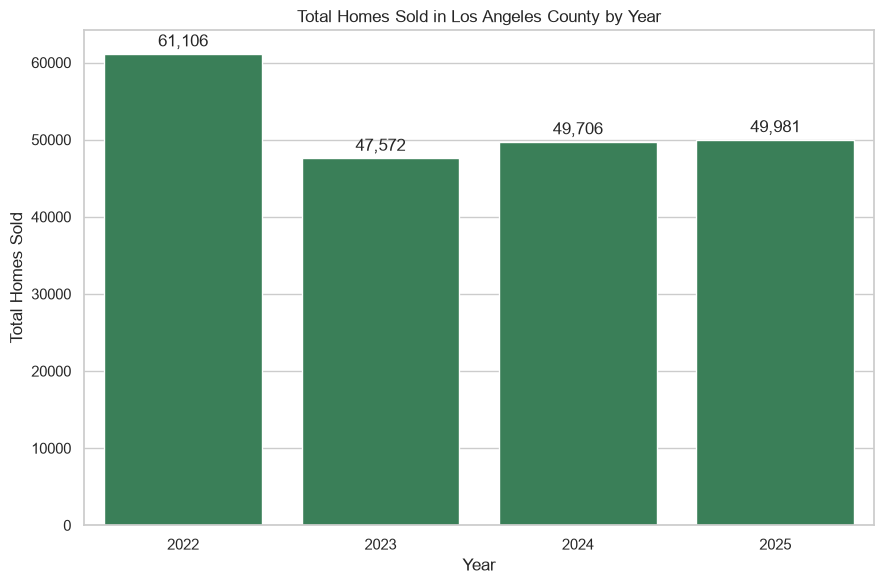

In [23]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=demand_summary,
    x="Year",
    y="Total Homes Sold",
    color="seagreen"
)

plt.title(
    "Total Homes Sold in Los Angeles County by Year"
)
plt.xlabel("Year")
plt.ylabel("Total Homes Sold")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value:,.0f}"
            for value in demand_summary[
                "Total Homes Sold"
            ]
        ],
        padding=3
    )

plt.tight_layout()
plt.show()

In [24]:
sales_2022 = demand_summary.loc[
    demand_summary["Year"] == 2022,
    "Total Homes Sold"
].iloc[0]

sales_2025 = demand_summary.loc[
    demand_summary["Year"] == 2025,
    "Total Homes Sold"
].iloc[0]

sales_total_change = (
    sales_2025 / sales_2022 - 1
) * 100

print(f"Total homes sold in 2022: {sales_2022:,.0f}")
print(f"Total homes sold in 2025: {sales_2025:,.0f}")
print(
    f"Change from 2022 to 2025: "
    f"{sales_total_change:.2f}%"
)

Total homes sold in 2022: 61,106
Total homes sold in 2025: 49,981
Change from 2022 to 2025: -18.21%


In [25]:
dom_2022 = demand_summary.loc[
    demand_summary["Year"] == 2022,
    "Average Days on Market"
].iloc[0]

dom_2025 = demand_summary.loc[
    demand_summary["Year"] == 2025,
    "Average Days on Market"
].iloc[0]

dom_change = dom_2025 - dom_2022

print(
    f"Average days on market in 2022: "
    f"{dom_2022:.2f} days"
)

print(
    f"Average days on market in 2025: "
    f"{dom_2025:.2f} days"
)

print(
    f"Increase from 2022 to 2025: "
    f"{dom_change:.2f} days"
)

Average days on market in 2022: 36.58 days
Average days on market in 2025: 49.92 days
Increase from 2022 to 2025: 13.33 days


### Analysis

Housing market activity in Los Angeles County weakened considerably after 2022.

Total homes sold decreased from 61,106 in 2022 to 47,572 in 2023, representing a decline of approximately 22.15%. Sales recovered moderately to 49,706 in 2024 and 49,981 in 2025. However, the 2025 total remained approximately 18.21% below the 2022 level.

Average pending sales also decreased from approximately 5,613 per month in 2022 to 4,584 in 2023. Pending sales recovered slightly in 2024 and 2025 but remained below the 2022 level.

At the same time, homes took longer to sell. Average median days on market increased from approximately 36.58 days in 2022 to 49.92 days in 2025, an increase of about 13.33 days.

Together, lower sales volume, fewer pending sales, and longer selling times suggest that buyer activity and market competition weakened compared with 2022. However, these indicators measure completed or near-completed transactions and do not capture all potential housing demand.

## 9. Problem 4: What Was the Relationship Between Home Prices, Supply, and Demand?

This section examines the relationship between home-price growth, housing supply, and market activity in Los Angeles County.

The analysis uses year-over-year changes calculated from the 48 monthly observations. Year-over-year changes compare each month with the same month one year earlier, helping reduce the influence of seasonal housing-market patterns.

In [26]:
# Calculate year-over-year changes from the monthly data

la["PRICE_YOY"] = (
    la["MEDIAN SALE PRICE NSA ($)"].pct_change(12) * 100
)

la["INVENTORY_YOY"] = (
    la["ACTIVE LISTINGS"].pct_change(12) * 100
)

la["NEW_LISTINGS_YOY"] = (
    la["NEW LISTINGS"].pct_change(12) * 100
)

la["SALES_YOY"] = (
    la["HOMES SOLD"].pct_change(12) * 100
)

la["PENDING_YOY"] = (
    la["PENDING SALES"].pct_change(12) * 100
)

la["DOM_YOY"] = (
    la["MEDIAN DAYS ON MARKET (DAYS)"].pct_change(12) * 100
)

In [27]:
relationship_data = la[
    [
        "PERIOD BEGIN",
        "PRICE_YOY",
        "INVENTORY_YOY",
        "NEW_LISTINGS_YOY",
        "SALES_YOY",
        "PENDING_YOY",
        "DOM_YOY"
    ]
].dropna().copy()

print(
    "Number of monthly observations:",
    len(relationship_data)
)

relationship_data.head()

Number of monthly observations: 36


,PERIOD BEGIN,PRICE_YOY,INVENTORY_YOY,NEW_LISTINGS_YOY,SALES_YOY,PENDING_YOY,DOM_YOY
12,2023-01-01,-3.636364,5.367232,-29.283172,-40.967608,-29.227941,51.282051
13,2023-02-01,-5.357143,-2.550695,-36.355422,-34.385666,-26.682967,75.000000
14,2023-03-01,-6.285714,-9.143958,-33.151138,-31.943602,-26.401345,53.571429
15,2023-04-01,-8.083333,-14.564069,-35.891878,-38.435055,-27.976104,37.037037
16,2023-05-01,-6.361111,-15.672842,-27.525000,-22.220381,-21.306194,25.925926


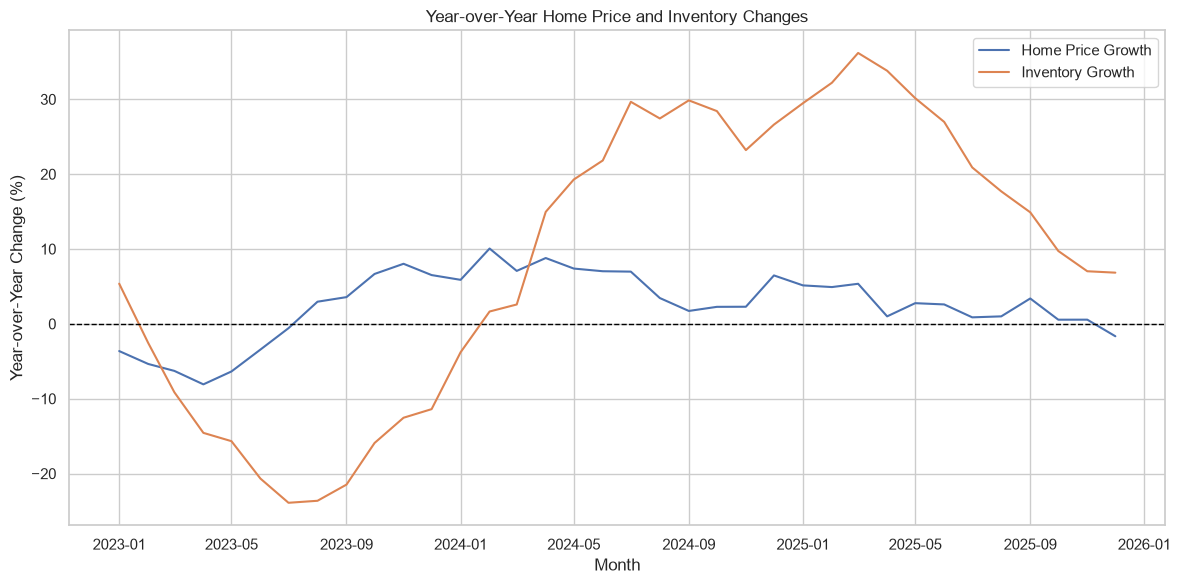

In [28]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=relationship_data,
    x="PERIOD BEGIN",
    y="PRICE_YOY",
    label="Home Price Growth"
)

sns.lineplot(
    data=relationship_data,
    x="PERIOD BEGIN",
    y="INVENTORY_YOY",
    label="Inventory Growth"
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "Year-over-Year Home Price and Inventory Changes"
)
plt.xlabel("Month")
plt.ylabel("Year-over-Year Change (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
correlation_columns = [
    "PRICE_YOY",
    "INVENTORY_YOY",
    "NEW_LISTINGS_YOY",
    "SALES_YOY",
    "PENDING_YOY",
    "DOM_YOY"
]

relationship_correlation = relationship_data[
    correlation_columns
].corr()

relationship_correlation.round(2)

,PRICE_YOY,INVENTORY_YOY,NEW_LISTINGS_YOY,SALES_YOY,PENDING_YOY,DOM_YOY
PRICE_YOY,1.00,0.31,0.85,0.71,0.69,-0.72
INVENTORY_YOY,0.31,1.00,0.66,0.59,0.65,0.28
NEW_LISTINGS_YOY,0.85,0.66,1.00,0.83,0.84,-0.45
SALES_YOY,0.71,0.59,0.83,1.00,0.94,-0.39
PENDING_YOY,0.69,0.65,0.84,0.94,1.00,-0.34
DOM_YOY,-0.72,0.28,-0.45,-0.39,-0.34,1.00


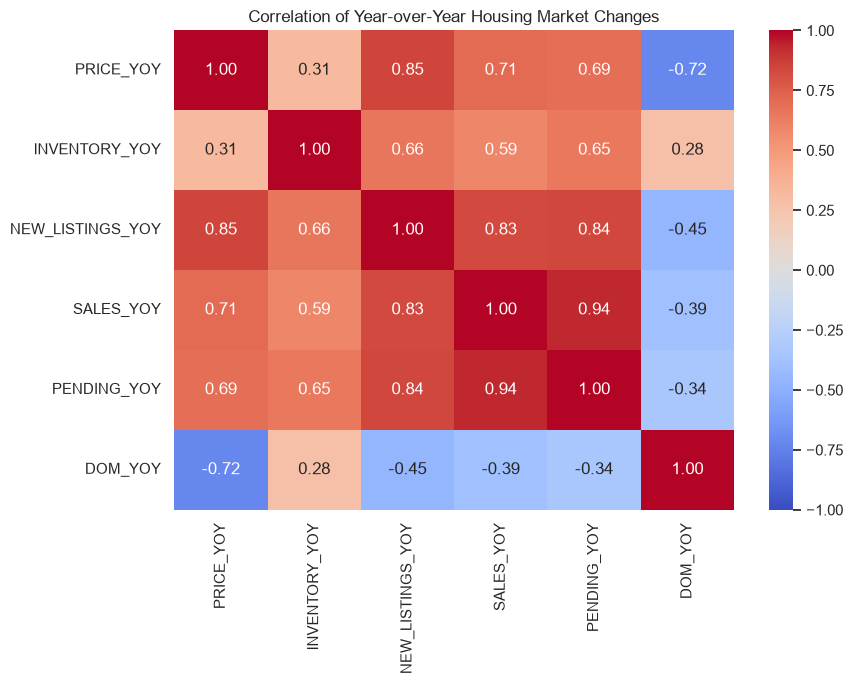

In [30]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    relationship_correlation,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title(
    "Correlation of Year-over-Year Housing Market Changes"
)
plt.tight_layout()
plt.show()

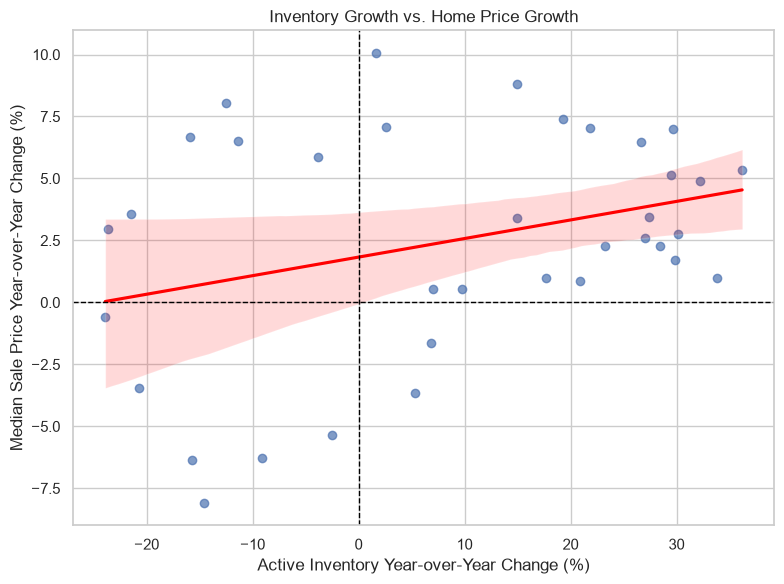

In [31]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=relationship_data,
    x="INVENTORY_YOY",
    y="PRICE_YOY",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "Inventory Growth vs. Home Price Growth"
)
plt.xlabel("Active Inventory Year-over-Year Change (%)")
plt.ylabel("Median Sale Price Year-over-Year Change (%)")
plt.tight_layout()
plt.show()

### Analysis

The monthly year-over-year analysis shows that the relationship between housing supply and home prices was more complex than a simple inverse relationship.

The correlation between active-inventory growth and home-price growth was approximately 0.31. This relatively weak positive relationship indicates that increasing inventory was not consistently associated with falling prices during the study period.

Home-price growth had stronger positive correlations with new-listing growth, homes-sold growth, and pending-sales growth. This suggests that periods with stronger transaction activity also tended to experience stronger price growth.

The relationship between home-price growth and changes in median days on market was approximately -0.72. Therefore, stronger price growth generally occurred when homes were selling more quickly, while slower-selling market conditions tended to be associated with weaker price growth.

Overall, the results suggest that increasing inventory alone was not sufficient to reduce Los Angeles County home prices. Market activity, selling speed, affordability, mortgage rates, and the types of homes sold may also have influenced price movements.

These correlations describe statistical relationships and do not prove that changes in supply or demand caused changes in home prices.

## Limitations

- The analysis covers January 2022 through December 2025 (48 monthly observations), so it describes recent market conditions rather than a full long-term housing cycle.
- County-level aggregates can hide differences among cities and neighborhoods within Los Angeles County.
- Correlation analysis identifies relationships in the observed data but does not establish causation.


## 10. Overall Conclusion

This project analyzed 48 monthly observations from January 2022 through December 2025 to examine home-price growth and supply–demand conditions in Los Angeles County.

Home prices increased overall but did not rise continuously. The median sale price increased from $825,000 in January 2022 to $890,000 in December 2025, representing cumulative growth of approximately 7.88%. Based on annual monthly averages, prices declined slightly in 2023 before increasing by 5.72% in 2024 and 2.17% in 2025.

Housing supply tightened in 2023 and then recovered strongly. Average active listings fell by 14.83% in 2023, increased by 18.72% in 2024, and increased by another 21.37% in 2025. By 2025, average active inventory was approximately 22.73% higher than in 2022.

However, increasing inventory was accompanied by relatively weak market activity. Total homes sold in 2025 remained approximately 18.21% below the 2022 level. Homes also took longer to sell, with average median days on market increasing from 36.58 days in 2022 to 49.92 days in 2025.

The year-over-year correlation analysis showed that inventory growth and home-price growth had a relatively weak positive correlation of approximately 0.31. Home-price growth had stronger positive relationships with sales and pending-sales growth and a negative relationship with changes in days on market.

Overall, the Los Angeles County housing market shifted from tighter inventory in 2023 toward greater housing availability in 2024 and 2025. Nevertheless, the increase in available listings did not produce a broad decline in median prices. The market instead showed a combination of higher inventory, slower sales, weaker transaction volume, and resilient home prices.

### Market Interpretation

The results suggest that Los Angeles County became less competitive for buyers compared with 2022 because more homes were available and properties generally took longer to sell.

However, improved buyer choice did not necessarily mean improved affordability. Median home prices remained high and continued to increase in 2024 and 2025.

For sellers, longer selling times suggest that pricing strategy became increasingly important. For buyers, rising inventory may have created more choice and negotiating opportunities, even though overall home prices remained elevated.